In [35]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirzayasirabdullah07/software-defect-prediction-dataset/software_defect_prediction_dataset.csv
/kaggle/input/datasets/ziya07/software-defect-prediction-dataset/SoftwareDefectDataset.csv


In [44]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/ziya07/software-defect-prediction-dataset/SoftwareDefectDataset.csv")

X = df.drop("DEFECT_LABEL", axis=1)
y = df["DEFECT_LABEL"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



TypeError: 'tuple' object is not callable

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)





Logistic Accuracy: 0.465


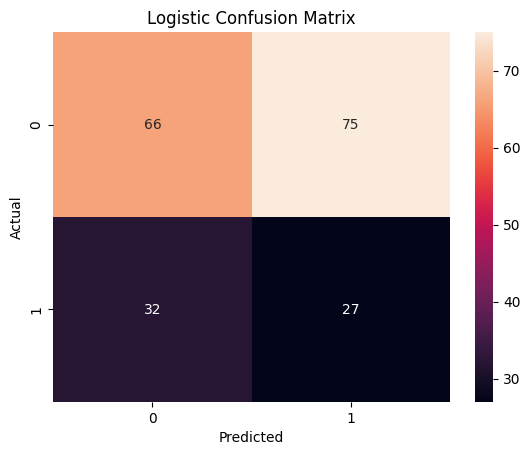


DecisionTree Accuracy: 0.57


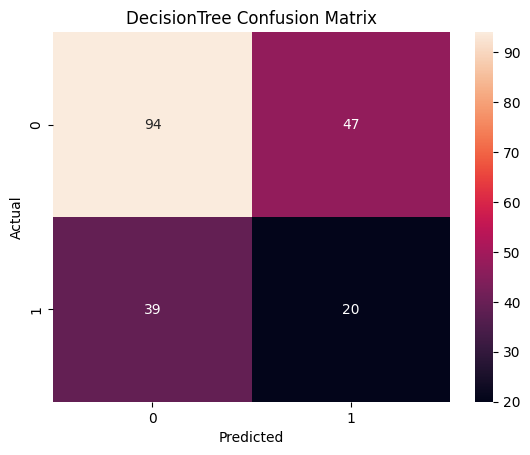


RandomForest Accuracy: 0.69


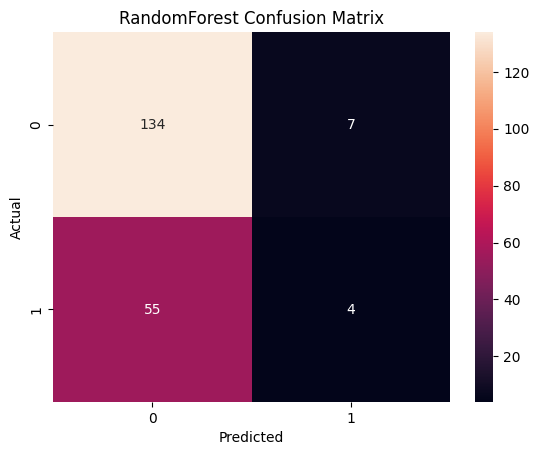


XGBoost Accuracy: 0.575


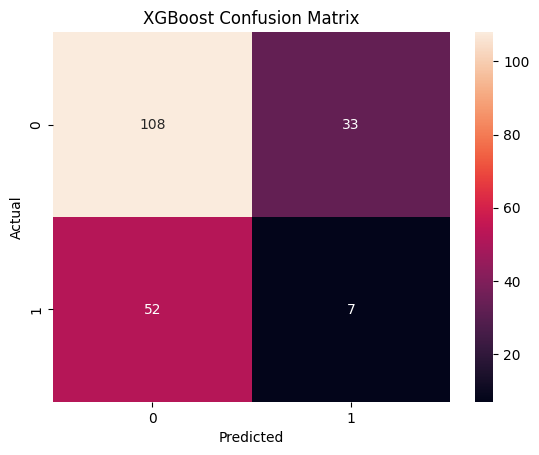

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

for name, y_pred in predictions.items():
    print(f"\n{name} Accuracy:", accuracy_score(y_test, y_pred))
    

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [39]:
from scipy.stats import ttest_ind

defective = df[df["DEFECT_LABEL"] == 1]["LOC"]
clean = df[df["DEFECT_LABEL"] == 0]["LOC"]

t_stat, p_val = ttest_ind(defective, clean)
print("T-test p-value:", p_val)

T-test p-value: 0.7434182689458374


In [40]:
from scipy.stats import ranksums

stat, p_val = ranksums(defective, clean)
print("Wilcoxon p-value:", p_val)

Wilcoxon p-value: 0.8187589015064296


In [41]:
from scipy.stats import friedmanchisquare

stat, p_val = friedmanchisquare(
    predictions["Logistic"],
    predictions["DecisionTree"],
    predictions["RandomForest"],
    predictions["XGBoost"]
)

print("Friedman p-value:", p_val)

Friedman p-value: 1.2493308234403254e-26


In [42]:
from scipy.stats import chi2_contingency

df["LOC_cat"] = pd.cut(df["LOC"], bins=3, labels=["low", "medium", "high"])

contingency = pd.crosstab(df["LOC_cat"], df["DEFECT_LABEL"])

chi2, p, _, _ = chi2_contingency(contingency)
print("Chi-square p-value:", p)

Chi-square p-value: 0.6474530160728251
